<a href="https://colab.research.google.com/github/LielUziahu/Stylophora-pistillata-FPs/blob/main/Planulae_CellCount.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== Descriptive Stats ===
       count          mean          std      min           25%           50%  \
morph                                                                          
HF       5.0  17039.047620  5959.466640  10200.0  11428.571430  19400.000000   
NF       6.0  16168.650793  9976.513426   4125.0  10473.214285  15988.095235   

                75%          max  
morph                             
HF     20166.666670  24000.00000  
NF     18239.583332  33285.71429  

=== T-Test Results ===
t-statistic: 0.1788
p-value: 0.8624


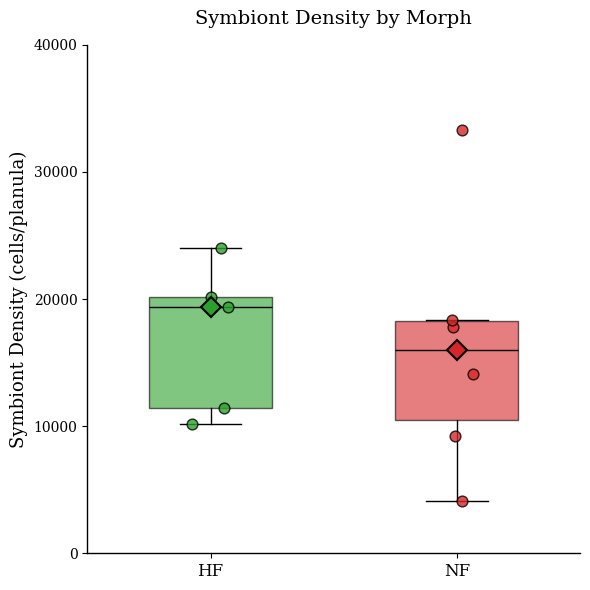

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import matplotlib.patches as mpatches

# ==========================================
# 1. SETUP & DATA LOADING
# ==========================================
filename = "Planulae_CellCount.csv"
df = pd.read_csv(filename)

# Rename the target column to something code-friendly (no slashes)
df = df.rename(columns={"Cell/Planulae": "CellCount"})
# Ensure Morph column is standard
if 'Morph' in df.columns:
    df = df.rename(columns={"Morph": "morph"})

# Filter out any rows with missing data in key columns
df = df.dropna(subset=['morph', 'CellCount'])

# --- Define Order & Colors ---
morph_order = ["HF", "NF"]
variant_colors = {"HF": "#2ca02c", "NF": "#d62728"}

# ==========================================
# 2. STATISTICS (T-Test)
# ==========================================
# Since we only have 'morph' as a factor, we use a T-test (or Mann-Whitney)
group_hf = df[df["morph"] == "HF"]["CellCount"]
group_nf = df[df["morph"] == "NF"]["CellCount"]

print("=== Descriptive Stats ===")
print(df.groupby("morph")["CellCount"].describe())

# Check for significance
# Using Welch's t-test (does not assume equal variance)
t_stat, p_val = stats.ttest_ind(group_hf, group_nf, equal_var=False)
print(f"\n=== T-Test Results ===")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_val:.4f}")

# ==========================================
# 3. PLOT CONSTRUCTION
# ==========================================
plt.rcParams.update({
    "font.family": "serif",
    "axes.edgecolor": "black", "axes.linewidth": 1,
    "xtick.color": "black", "ytick.color": "black",
    "text.color": "black", "axes.labelcolor": "black",
    "legend.frameon": False
})

fig, ax = plt.subplots(figsize=(6, 6))

box_width = 0.5
# We only have one "x-axis" category (the Morph itself),
# so we can plot them at positions 0 and 1
positions = np.arange(len(morph_order))

for i, morph in enumerate(morph_order):
    sub = df[df["morph"] == morph]
    data_values = sub["CellCount"].values

    # A. Boxplot
    # We plot one box at a time at position 'i'
    bp = ax.boxplot(
        [data_values],
        positions=[i],
        widths=box_width,
        patch_artist=True,
        showfliers=False,
        zorder=2
    )

    # Style
    for patch in bp['boxes']:
        patch.set_facecolor(variant_colors[morph])
        patch.set_alpha(0.6)
        patch.set_edgecolor('black')
        patch.set_linewidth(1)
    for element in ['whiskers', 'caps', 'medians']:
        plt.setp(bp[element], color='black', linewidth=1)

    # B. Jittered Points
    # Create random x-jitter around the center position 'i'
    x_jitter = np.random.normal(i, 0.04, size=len(data_values))
    ax.scatter(
        x_jitter, data_values,
        s=60, c=variant_colors[morph],
        edgecolors="black", linewidths=1,
        alpha=0.8, zorder=3
    )

    # C. Median Diamond
    median_val = np.median(data_values)
    ax.plot(
        i, median_val,
        marker="D", linestyle="None",
        markersize=10,
        markerfacecolor=variant_colors[morph],
        markeredgecolor="black",
        markeredgewidth=1.5,
        zorder=4
    )

# ==========================================
# 4. LABELS & FORMATTING
# ==========================================
ax.set_ylabel("Symbiont Density (cells/planula)", fontsize=13)
#ax.set_xlabel("Morphotype", fontsize=13)
ax.set_title("Symbiont Density by Morph", fontsize=14, pad=15)

# Set X-ticks to be the morph names
ax.set_xticks(positions)
ax.set_xticklabels(morph_order, fontsize=12)

# Set y-axis ticks every 10000
y_min, y_max = df["CellCount"].min(), df["CellCount"].max()
y_ticks = np.arange(np.floor(y_min / 10000) * 10000, np.ceil(y_max / 10000) * 10000 + 1, 10000)
ax.set_yticks(y_ticks)

# Legend
#legend_handles = []
#for morph in morph_order:
#    patch = mpatches.Patch(color=variant_colors[morph], label=morph, edgecolor='black', linewidth=1, alpha=0.6)
#    legend_handles.append(patch)
#ax.legend(handles=legend_handles, labels=morph_order, loc="upper right")

sns.despine(ax=ax)
fig.tight_layout()

# Save
plt.savefig("Symbiont_Density_Plot.png", dpi=300)
plt.show()
